In [18]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score, KFold, validation_curve
from sklearn.datasets import make_regression

### What is Cross-Validation?

**Cross-Validation** is a technique to assess how well your model will generalize to new, unseen data by splitting your data multiple times and averaging the performance.


| Approach | Risk |
|----------|------|
| **Single Train-Test Split** | You might get lucky (or unlucky) with how the data is split |
| **Cross-Validation** | More reliable estimate of model performance |


> **The Golden Rule:** Never trust a single train-test split. Always use Cross-Validation.


1. Split data into **k folds**
2. Train on **k-1 folds**, test on the remaining **1 fold**
3. Repeat **k times** (each fold gets to be the test set once)
4. **Average** the performance across all k runs


In [2]:
# data
np.random.seed(42)
X = np.random.randn(100, 5)
y = 2*X[:, 0] + 0.5*X[:, 1] + np.random.randn(100) * 0.1

# split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor()
model.fit(X_train, y_train)
print(f"Single split MSE: {mean_squared_error(y_test, model.predict(X_test)):.3f}")

# different random states
for seed in [0, 1, 2, 3, 4]:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
    model.fit(X_train, y_train)
    mse = mean_squared_error(y_test, model.predict(X_test))
    print(f"Seed {seed}: MSE = {mse:.3f}")

Single split MSE: 0.137
Seed 0: MSE = 0.169
Seed 1: MSE = 0.309
Seed 2: MSE = 0.196
Seed 3: MSE = 0.078
Seed 4: MSE = 0.046


The Problem: Your performance estimate changes dramatically based on which 20% of data happened to end up in the test set. You could accidentally get lucky (0.072) or unlucky (0.103) and make the wrong decision about your model!



In [ ]:
Dataset: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]  (10 samples)

K-Fold (K=5):
┌─────────────────────────────────────────────────────────────┐
│ Fold 1: [1, 2]  │  [3, 4, 5, 6, 7, 8, 9, 10]             │
│ Fold 2: [3, 4]  │  [1, 2, 5, 6, 7, 8, 9, 10]             │
│ Fold 3: [5, 6]  │  [1, 2, 3, 4, 7, 8, 9, 10]             │
│ Fold 4: [7, 8]  │  [1, 2, 3, 4, 5, 6, 9, 10]             │
│ Fold 5: [9, 10] │  [1, 2, 3, 4, 5, 6, 7, 8]              │
└─────────────────────────────────────────────────────────────┘

Each fold: Train on 4 folds, Test on 1 fold
Final Score = Average of 5 test scores

In [12]:
# Best for: Most situations. Balanced bias-variance tradeoff.

from sklearn.model_selection import KFold

# data
X, y = make_regression(n_samples=200, n_features=5, noise=0.1, random_state=42)

# K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = RandomForestRegressor()

# scores for each fold
scores = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error')

# MSE
mse_scores = -scores
print(f"Individual fold MSEs: {mse_scores.round(4)}")
print(f"Mean MSE: {mse_scores.mean():.4f} ± {mse_scores.std():.4f}")

Individual fold MSEs: [794.9096 732.3145 955.9007 510.3874 636.2001]
Mean MSE: 725.9425 ± 149.7969


### Why Use `KFold` Explicitly Instead of Just `cv=5`?

Both methods work, but `KFold` gives you **more control**.


| Approach | Code | Control |
|----------|------|---------|
| **Simple** | `cross_val_score(model, X, y, cv=5)` | Minimal (default behavior) |
| **Explicit KFold** | `KFold(n_splits=5, shuffle=True, random_state=42)` | Full control over splitting |


What `cv=5` Does Behind the Scenes

```python
# This:
cross_val_score(model, X, y, cv=5)

# Is equivalent to this (without shuffle):
KFold(n_splits=5, shuffle=False, random_state=None)

In [14]:
# Leave-One-Out (LOOCV)
# Best for: Very small datasets (n < 50). Very high variance, computationally expensive.

from sklearn.model_selection import LeaveOneOut

# loo = LeaveOneOut()  # K = number of samples (n)
# scores = cross_val_score(model, X, y, cv=loo)


In [16]:
# Best for: Time series data. Prevents future data from leaking into training.

from sklearn.model_selection import TimeSeriesSplit

# tscv = TimeSeriesSplit(n_splits=5)
# Important: Uses chronological order, no shuffling!
# scores = cross_val_score(model, X, y, cv=tscv)

In [13]:
# Stratified K-Fold (For Classification)
# Best for: Classification with imbalanced classes. Prevents a fold from having all 0s or all 1s.

from sklearn.model_selection import StratifiedKFold

# Ensures each fold has the same class distribution as the whole dataset
# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# scores = cross_val_score(model, X, y, cv=skf)

### What is a Hyperparameter?

A **hyperparameter** is a setting or configuration that you choose **before** training a machine learning model. Unlike model parameters (which are learned from data), hyperparameters control **how** the model learns.

Parameters vs Hyperparameters

| Feature | **Model Parameters** | **Hyperparameters** |
|---------|----------------------|---------------------|
| **What they are** | Learned from data | Set before training |
| **Examples** | Weights, coefficients, biases | Learning rate, tree depth, alpha |
| **Who sets them** | The algorithm during training | You (the data scientist) |
| **Change during training?** | Yes, they update | No, they stay fixed |
| **Found by** | Gradient descent, optimization | Trial and error, grid search, tuning |


### What Does a Cross-Validation Curve Do?

A **Cross-Validation Curve** shows how a model's performance changes as you vary a hyperparameter.

It helps you find the **sweet spot** — the hyperparameter value that gives the best validation performance without overfitting.


The curve typically plots:

| X-Axis | Y-Axis |
|--------|--------|
| Hyperparameter value (e.g., alpha, max_depth, C) | CV Score (e.g., accuracy, R², F1) |


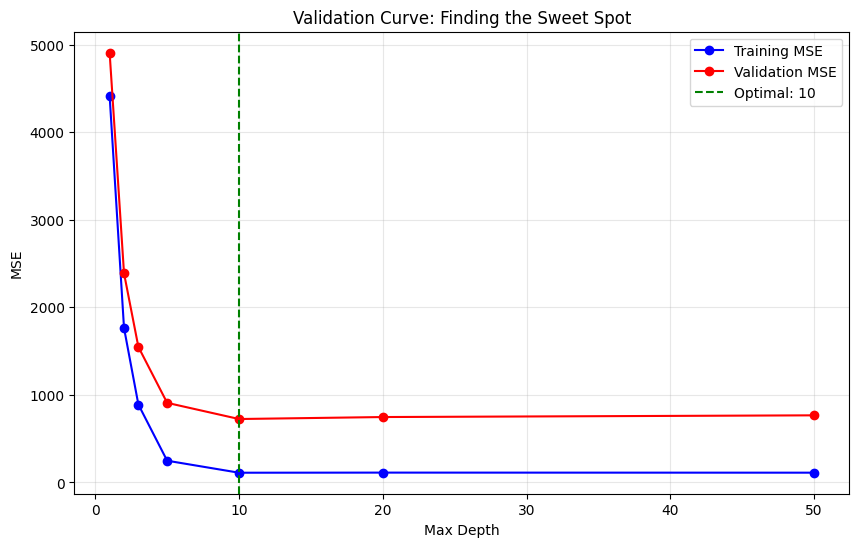

Optimal max_depth: 10
Minimum validation MSE: 724.2162


In [19]:
# different model complexities
param_range = [1, 2, 3, 5, 10, 20, 50]
train_scores, val_scores = validation_curve(
    RandomForestRegressor(),
    X, y,
    param_name='max_depth',
    param_range=param_range,
    cv=5,
    scoring='neg_mean_squared_error'
)

# MSE
train_mse = -train_scores.mean(axis=1)
val_mse = -val_scores.mean(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(param_range, train_mse, 'o-', label='Training MSE', color='blue')
plt.plot(param_range, val_mse, 'o-', label='Validation MSE', color='red')
plt.xlabel('Max Depth')
plt.ylabel('MSE')
plt.title('Validation Curve: Finding the Sweet Spot')
plt.legend()
plt.grid(alpha=0.3)

# find optimal depth
optimal_idx = np.argmin(val_mse)
plt.axvline(param_range[optimal_idx], color='green', linestyle='--', 
            label=f'Optimal: {param_range[optimal_idx]}')
plt.legend()
plt.show()

print(f"Optimal max_depth: {param_range[optimal_idx]}")
print(f"Minimum validation MSE: {val_mse[optimal_idx]:.4f}")